In [1]:
!nvidia-smi

Thu Jun 25 06:00:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import shutil

# Environment detection and setup
if os.path.exists('/kaggle/working'):
    print('Running on Kaggle. Setting up working directory...')
    dataset_paths = [
        '/kaggle/input/datasets/duongthanhduy/model-lnl/Locality-iN-Locality',
        '/kaggle/input/model-lnl/Locality-iN-Locality'
    ]
    src_dir = None
    for path in dataset_paths:
        if os.path.exists(path):
            src_dir = path
            break
            
    if src_dir is None:
        for root, dirs, files in os.walk('/kaggle/input'):
            for d in dirs:
                if d == 'Locality-iN-Locality':
                    src_dir = os.path.join(root, d)
                    break
            if src_dir:
                break
                
    if src_dir:
        print(f'Found source code dataset at: {src_dir}')
        for item in os.listdir(src_dir):
            s = os.path.join(src_dir, item)
            d = os.path.join('/kaggle/working', item)
            if os.path.isdir(s):
                if os.path.exists(d):
                    shutil.rmtree(d)
                shutil.copytree(s, d)
            else:
                shutil.copy2(s, d)
        print('Successfully copied all source files to /kaggle/working.')
    else:
        print('Warning: Could not find Locality-iN-Locality source folder under /kaggle/input.')
        
    os.chdir('/kaggle/working')
    print('Current working directory changed to:', os.getcwd())
else:
    print('Running on Colab/Local.')
    if not os.path.exists('Locality-iN-Locality'):
        !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git
    os.chdir('Locality-iN-Locality')
    print('Current working directory changed to:', os.getcwd())

Running on Kaggle. Setting up working directory...
Found source code dataset at: /kaggle/input/datasets/duongthanhduy/model-lnl/Locality-iN-Locality
Successfully copied all source files to /kaggle/working.
Current working directory changed to: /kaggle/working


In [ ]:
# Handled in the previous environment setup cell

In [3]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
     

In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [5]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.10.0+cu128
Torchvision 0.25.0+cu128
Torchattacks 3.5.1
Numpy 2.4.6


## GTSRB

In [6]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  15.3M      0  0:00:17  0:00:17 --:--:-- 15.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  11.0M      0  0:00:07  0:00:07 --:--:-- 14.4M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  90306      0  0:00:01  0:00:01 --:--:-- 90317


In [7]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [8]:
import shutil

In [9]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]
  

  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [ ]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7) 
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]
                   

In [10]:
batch_size = 64

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([                   
                                                          transforms.Resize((224,224)),
                                                          transforms.RandomRotation(15),
                                                          transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                                                          transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                                                          transforms.ToTensor(),
                                                          transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([                    
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True,
                                         num_workers=2,
                                         pin_memory=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=False,
                                         num_workers=2,
                                         pin_memory=True
                                         )

In [11]:
batch = next(iter(train_loader))
train_data = batch[0]

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)
        
        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

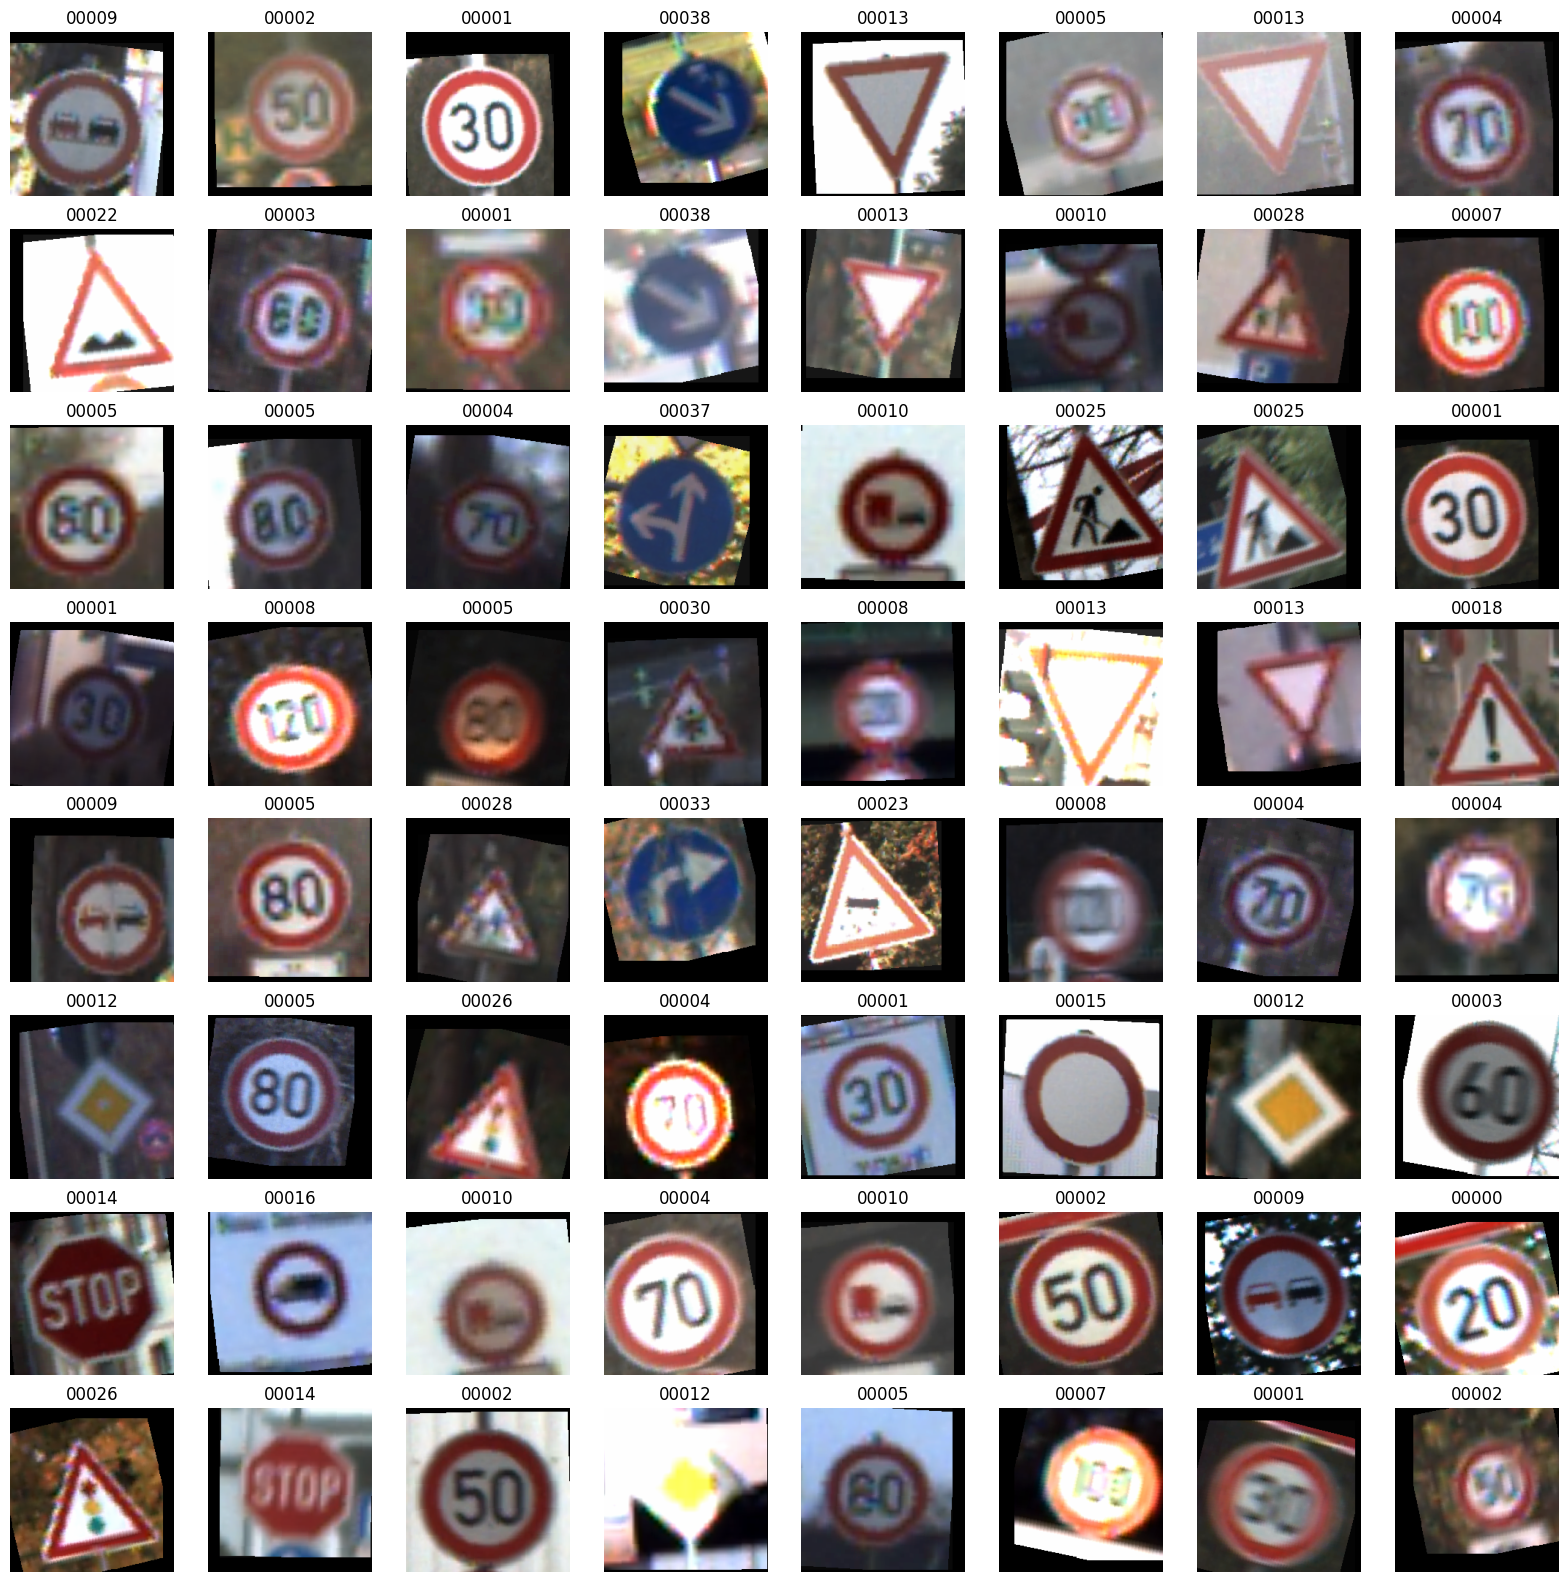

In [13]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [14]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install einops

Note: you may need to restart the kernel to use updated packages.


In [16]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/kaggle/working/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered conflicts wit

In [17]:
model = small(pretrained=False)

In [18]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [19]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [20]:
model = model.cuda()

## Train Locality-iN-Locality

In [ ]:
# num_epochs = 35

In [ ]:
# loss = nn.CrossEntropyLoss(label_smoothing=0.1)
# optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)

## Cosine annealing learning rate schedule with linear warmup
# import math
# def adjust_learning_rate(optimizer, epoch, warmup_epochs=5, total_epochs=35, base_lr=0.0005):
   # if epoch < warmup_epochs:
    #    lr = base_lr * (epoch + 1) / warmup_epochs
   # else:
    #    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    #    lr = base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
   # for param_group in optimizer.param_groups:
    #    param_group['lr'] = lr
    # return lr

In [ ]:
# best_acc = 0.0
# for epoch in range(num_epochs):
#     lr = adjust_learning_rate(optimizer, epoch, total_epochs=num_epochs)
#     total_batch = len(trainset) // batch_size
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
#     
#     for i, (batch_images, batch_labels) in enumerate(train_loader):
#         X = batch_images.cuda()
#         Y = batch_labels.cuda()
#
#         pre = model(X)
#         cost = loss(pre, Y)
#
#         optimizer.zero_grad()
#         cost.backward()
#         optimizer.step()
#         
#         running_loss += cost.item() * X.size(0)
#         _, predicted = pre.max(1)
#         total += Y.size(0)
#         correct += predicted.eq(Y).sum().item()
#
#         if (i+1) % 100 == 0:
#             print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
#                  %(epoch+1, num_epochs, i+1, total_batch, cost.item()))
#              
#     epoch_loss = running_loss / len(trainset)
#     epoch_acc = 100.0 * correct / total
#     
#     # Evaluate on test set
#     model.eval()
#     test_correct = 0
#     test_total = 0
#     with torch.no_grad():
#         for test_input, test_target in test_loader:
#             test_input, test_target = test_input.cuda(), test_target.cuda()
#             test_output = model(test_input)
#             _, test_predicted = test_output.max(1)
#             test_total += test_target.size(0)
#             test_correct += test_predicted.eq(test_target).sum().item()
#     test_acc = 100.0 * test_correct / test_total
#     
#     print(f'==> Epoch {epoch+1} Complete: Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Test Acc: {test_acc:.2f}% (LR={lr:.6f})')
#     
#     if test_acc > best_acc:
#         best_acc = test_acc
#         torch.save({'model': model.state_dict(), 'acc': test_acc, 'epoch': epoch}, 'best_model_lnl_ti.pth')
#         print(f'  New best test accuracy saved: {test_acc:.2f}%')


## Test

In [ ]:
# model.eval()
# correct = 0
# total = 0

# for images, labels in test_loader:
    
  #  images = images.cuda()
  #  outputs = model(images)
    
  #  _, predicted = torch.max(outputs.data, 1)
    
  #  total += labels.size(0)
  # correct += (predicted == labels.cuda()).sum()
    
# print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

## FGSM attack

In [ ]:
# model.eval()

# correct = 0
# total = 0

# atk = FGSM(model, eps=0.01)

# for images, labels in test_loader:
    
  #  images = atk(images, labels).cuda()
  #  outputs = model(images)
    
  #  _, predicted = torch.max(outputs.data, 1)
    
  #  total += labels.size(0)
  #  correct += (predicted == labels.cuda()).sum()
    
# print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

## PGD attack

In [ ]:
# model.eval()
#
# correct = 0
# total = 0
#
# atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)
#
# for images, labels in test_loader:
#     
#     images = atk(images, labels).cuda()
#     outputs = model(images)
#     
#     _, predicted = torch.max(outputs.data, 1)
#     
#     total += labels.size(0)
#     correct += (predicted == labels.cuda()).sum()
#     
# print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))


## train LNL-MoEx

In [ ]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

In [ ]:
import time
# time.clock_gettime()

In [ ]:
num_epochs = 35
moex_lam = .9
moex_prob = .7

In [ ]:
loss = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)

# Cosine annealing learning rate schedule with linear warmup
import math
def adjust_learning_rate(optimizer, epoch, warmup_epochs=5, total_epochs=35, base_lr=0.0005):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        lr = base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

In [ ]:
best_acc = 0.0
for epoch in range(num_epochs):
    lr = adjust_learning_rate(optimizer, epoch, total_epochs=num_epochs)
    total_batch = len(trainset) // batch_size
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            cost = loss(output, target)

        # compute gradient and do SGD/AdamW step
        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        running_loss += cost.item() * input.size(0)
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

        if (i+1) % 100 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))
             
    epoch_loss = running_loss / len(trainset)
    epoch_acc = 100.0 * correct / total
    
    # Evaluate on test set
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for test_input, test_target in test_loader:
            test_input, test_target = test_input.cuda(), test_target.cuda()
            test_output = model(test_input)
            _, test_predicted = test_output.max(1)
            test_total += test_target.size(0)
            test_correct += test_predicted.eq(test_target).sum().item()
    test_acc = 100.0 * test_correct / test_total
    
    print(f'==> Epoch {epoch+1} Complete: Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Test Acc: {test_acc:.2f}% (LR={lr:.6f})')
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({'model': model.state_dict(), 'acc': test_acc, 'epoch': epoch}, 'best_model_lnl_moex_ti.pth')
        print(f'  New best test accuracy saved: {test_acc:.2f}%')

## Download weight 

In [ ]:
from IPython.display import FileLink
FileLink('best_model_lnl_moex_ti.pth')


## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


## Load model weight and inference

In [21]:
import os
import sys
import shutil

# 1. Tự động kiểm tra và sao chép mã nguồn nếu chạy trên session Kaggle mới
if os.path.exists('/kaggle/working'):
    os.chdir('/kaggle/working')
    if '/kaggle/working' not in sys.path:
        sys.path.append('/kaggle/working')
    
    # Kiểm tra xem code đã được copy chưa, nếu chưa thì tiến hành copy
    if not os.path.exists('/kaggle/working/LNL_MoEx.py'):
        print("Đang thiết lập môi trường và sao chép mã nguồn vào thư mục làm việc...")
        dataset_paths = [
            '/kaggle/input/datasets/duongthanhduy/model-lnl/Locality-iN-Locality',
            '/kaggle/input/model-lnl/Locality-iN-Locality'
        ]
        src_dir = None
        for path in dataset_paths:
            if os.path.exists(path):
                src_dir = path
                break
                
        if src_dir is None:
            # Tự động tìm kiếm nếu thư mục nằm ở đường dẫn khác
            for root, dirs, files in os.walk('/kaggle/input'):
                for d in dirs:
                    if d == 'Locality-iN-Locality':
                        src_dir = os.path.join(root, d)
                        break
                if src_dir:
                    break
                    
        if src_dir:
            for item in os.listdir(src_dir):
                s = os.path.join(src_dir, item)
                d = os.path.join('/kaggle/working', item)
                if os.path.isdir(s):
                    if os.path.exists(d):
                        shutil.rmtree(d)
                    shutil.copytree(s, d)
                else:
                    shutil.copy2(s, d)
            print("Thiết lập môi trường và sao chép mã nguồn hoàn tất!")
        else:
            print("Cảnh báo: Không tìm thấy thư mục mã nguồn Locality-iN-Locality trong /kaggle/input.")

# 2. Khai báo cấu trúc mô hình LNL-MoEx
import torch
import torch.nn as nn
from LNL_MoEx import LNL_MoEx_Ti as small

model = small(pretrained=False)
model.head = nn.Linear(in_features=192, out_features=43, bias=True)
model = model.cuda()

# 3. Load file weight đã train
checkpoint_path = '/kaggle/input/models/duongthanhduy/lnl-moex/pytorch/default/1/best_model_lnl_moex_ti.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cuda')
    model.load_state_dict(checkpoint['model'])
    print(f"Đã load thành công mô hình LNL-MoEx tại Epoch {checkpoint['epoch'] + 1}!")
    print(f"Độ chính xác tốt nhất đã ghi nhận: {checkpoint['acc']:.2f}%")
else:
    print(f"Lỗi: Không tìm thấy file weight tại đường dẫn: {checkpoint_path}")


/kaggle/working/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/kaggle/working/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/kaggle/working/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


Đã load thành công mô hình LNL-MoEx tại Epoch 35!
Độ chính xác tốt nhất đã ghi nhận: 99.68%


ID  | Nhãn Gốc thực tế (GT)               | Mô hình dự đoán (Pred)              | Kết quả   
----------------------------------------------------------------------------------------------------
00  | Hạn chế tốc độ (20km/h)             | Hạn chế tốc độ (20km/h)             | ✅ OK
01  | Hạn chế tốc độ (30km/h)             | Hạn chế tốc độ (30km/h)             | ✅ OK
02  | Hạn chế tốc độ (50km/h)             | Hạn chế tốc độ (50km/h)             | ✅ OK
03  | Hạn chế tốc độ (60km/h)             | Hạn chế tốc độ (60km/h)             | ✅ OK
04  | Hạn chế tốc độ (70km/h)             | Hạn chế tốc độ (70km/h)             | ✅ OK
05  | Hạn chế tốc độ (80km/h)             | Hạn chế tốc độ (80km/h)             | ✅ OK
06  | Hết hạn chế tốc độ (80km/h)         | Hết hạn chế tốc độ (80km/h)         | ✅ OK
07  | Hạn chế tốc độ (100km/h)            | Hạn chế tốc độ (100km/h)            | ✅ OK
08  | Hạn chế tốc độ (120km/h)            | Hạn chế tốc độ (120km/h)            | ✅ OK
09  | Cấm vượt         

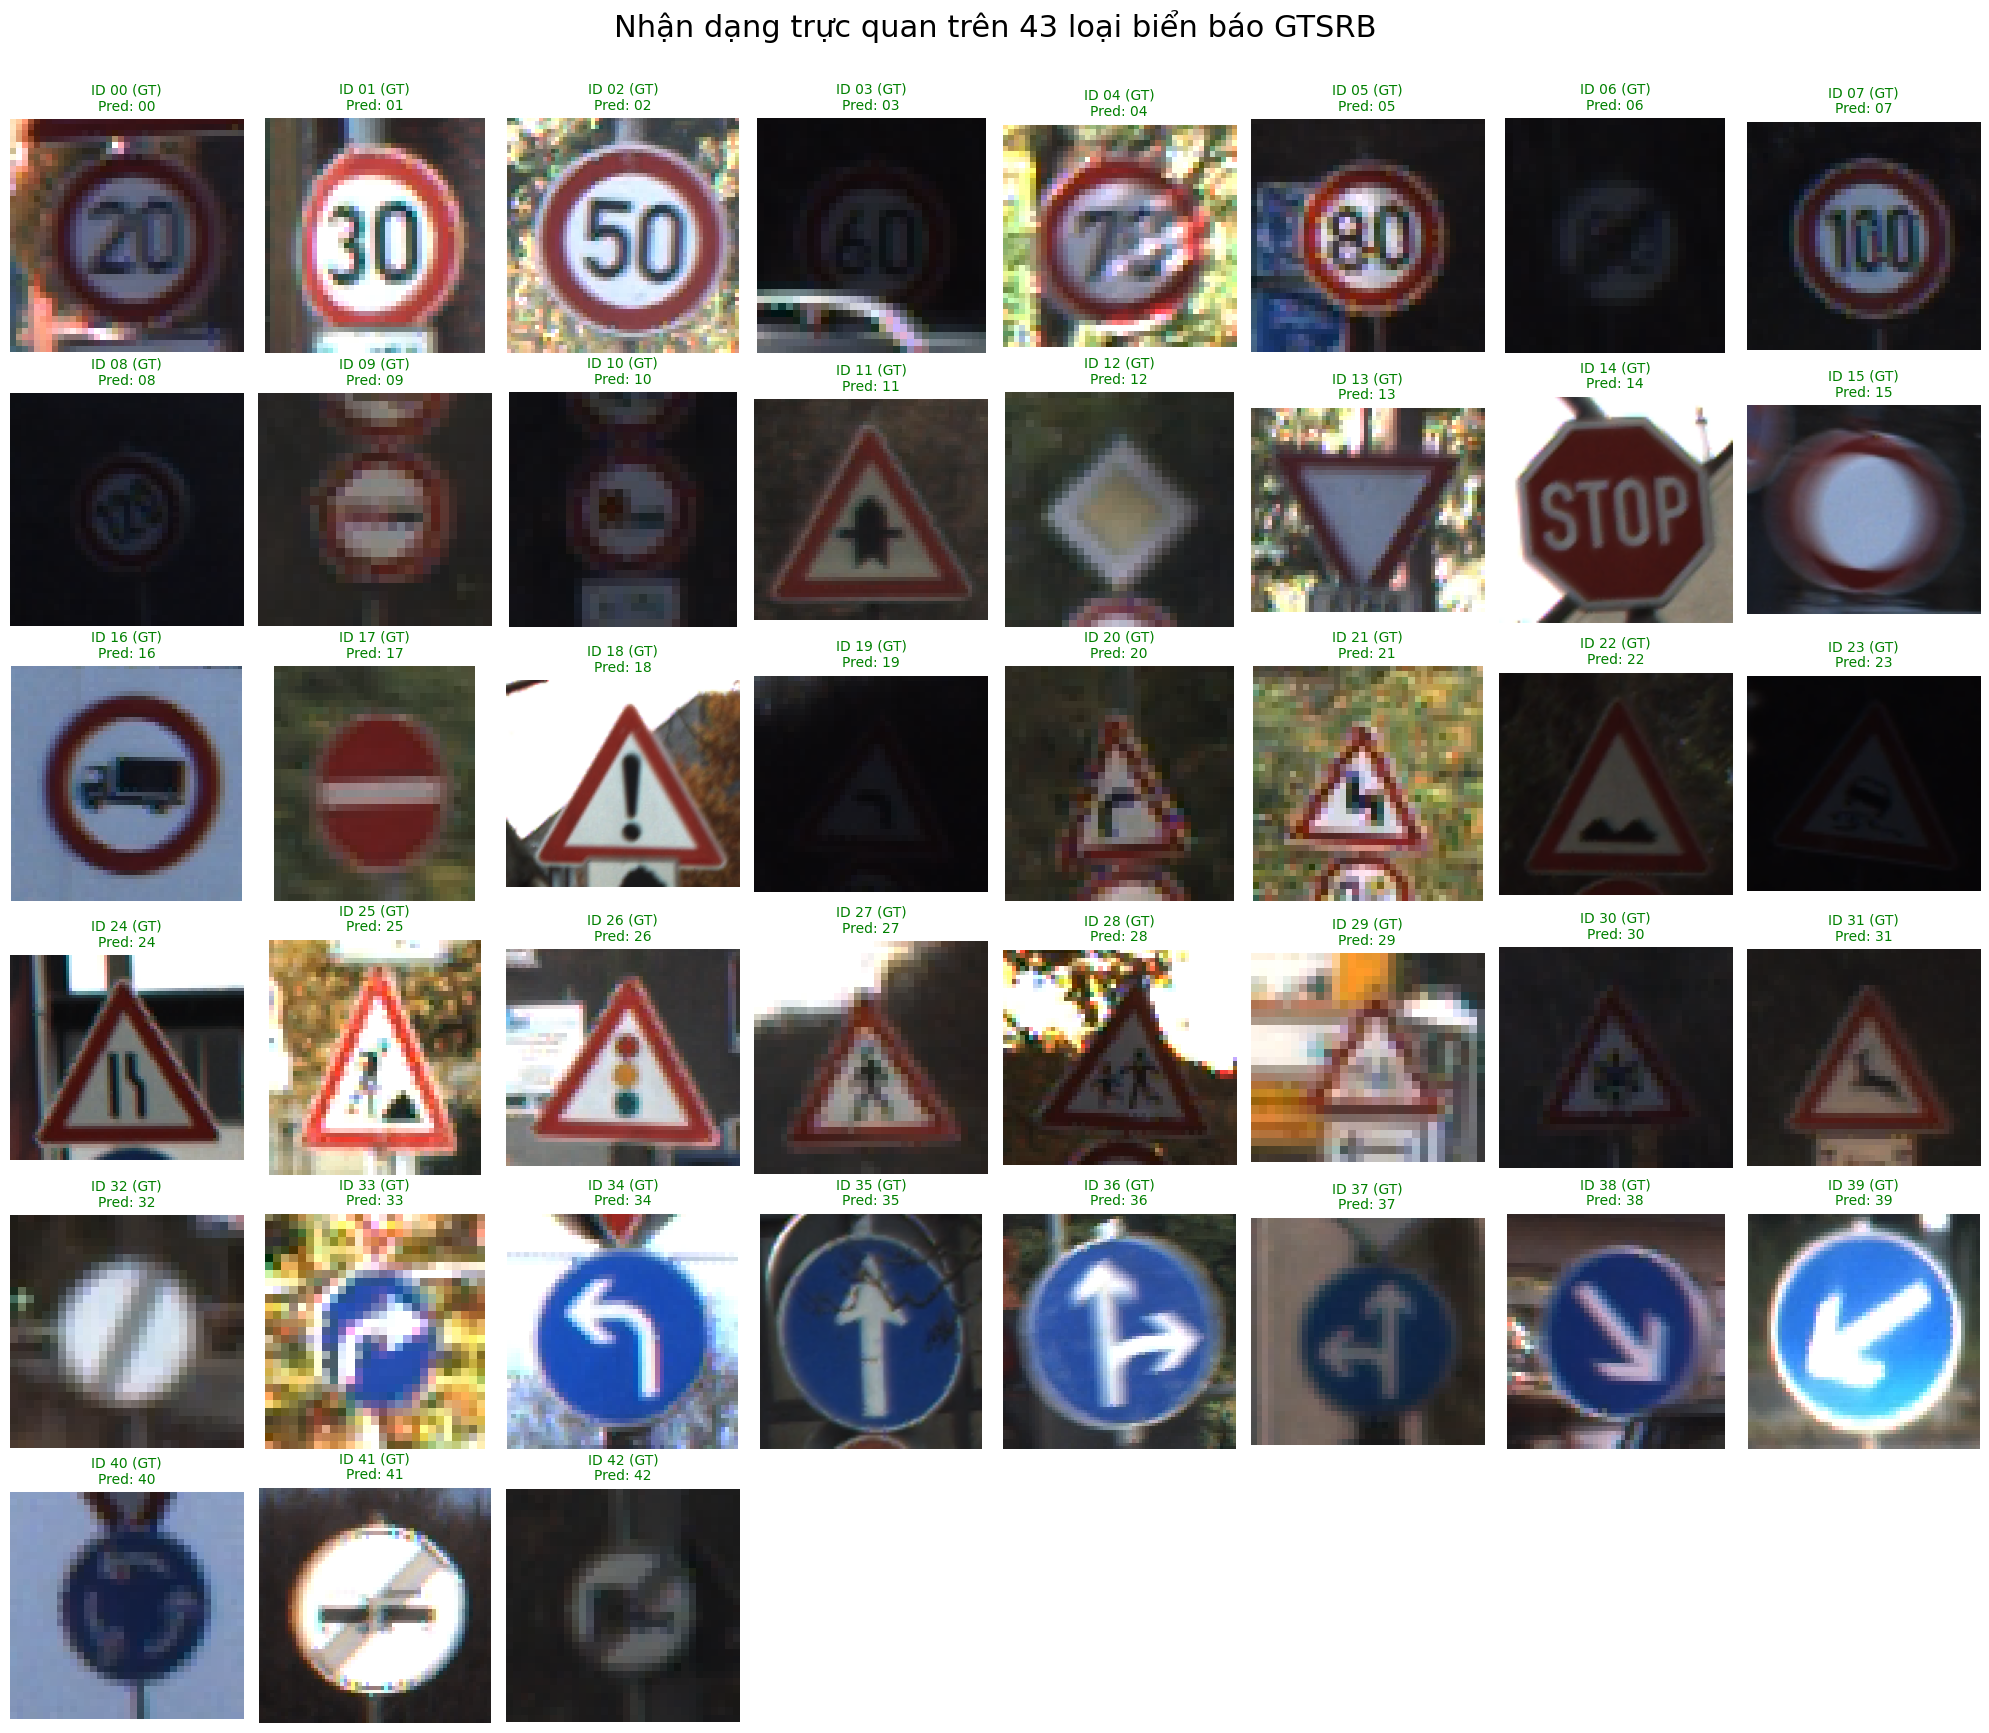

In [22]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Từ điển dịch tên biển báo GTSRB sang Tiếng Việt
GTSRB_LABELS_VI = {
    0: "Hạn chế tốc độ (20km/h)",
    1: "Hạn chế tốc độ (30km/h)",
    2: "Hạn chế tốc độ (50km/h)",
    3: "Hạn chế tốc độ (60km/h)",
    4: "Hạn chế tốc độ (70km/h)",
    5: "Hạn chế tốc độ (80km/h)",
    6: "Hết hạn chế tốc độ (80km/h)",
    7: "Hạn chế tốc độ (100km/h)",
    8: "Hạn chế tốc độ (120km/h)",
    9: "Cấm vượt",
    10: "Cấm xe tải > 3.5t vượt",
    11: "Giao nhau ưu tiên cắt ngang",
    12: "Đường ưu tiên",
    13: "Nhường đường (Yield)",
    14: "Dừng lại (Stop)",
    15: "Đường cấm phương tiện",
    16: "Cấm xe tải trên 3.5 tấn",
    17: "Cấm đi ngược chiều",
    18: "Cảnh báo nguy hiểm khác",
    19: "Chỗ ngoặt nguy hiểm bên trái",
    20: "Chỗ ngoặt nguy hiểm bên phải",
    21: "Đường vòng liên tiếp",
    22: "Đường lồi lõm (ổ gà)",
    23: "Đường trơn trượt",
    24: "Đường hẹp bên phải",
    25: "Công trường đang thi công",
    26: "Giao nhau có đèn tín hiệu",
    27: "Đường người đi bộ sang ngang",
    28: "Trẻ em qua đường",
    29: "Người đi xe đạp qua đường",
    30: "Cảnh báo băng tuyết trơn",
    31: "Thú rừng băng qua đường",
    32: "Hết tất cả các lệnh hạn chế",
    33: "Bắt buộc rẽ phải phía trước",
    34: "Bắt buộc rẽ trái phía trước",
    35: "Bắt buộc đi thẳng",
    36: "Bắt buộc đi thẳng/rẽ phải",
    37: "Bắt buộc đi thẳng/rẽ trái",
    38: "Đi tránh sang bên phải",
    39: "Đi tránh sang bên trái",
    40: "Vòng xoay bắt buộc",
    41: "Hết lệnh cấm vượt",
    42: "Hết cấm xe tải > 3.5t vượt"
}

# 2. Đảm bảo mô hình ở chế độ eval
model.eval()

# 3. Lấy danh sách ảnh đại diện cho mỗi lớp (từ 0 đến 42) trong tập Test
class_samples = {}
for path, label in testset.samples:
    if label not in class_samples:
        class_samples[label] = path
    if len(class_samples) == 43:
        break

# 4. Định nghĩa phép biến đổi cho ảnh đầu vào (Inference Transform)
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 5. Tạo Grid trực quan hóa 43 ảnh
fig = plt.figure(figsize=(20, 18))
plt.suptitle("Nhận dạng trực quan trên 43 loại biển báo GTSRB", fontsize=22, y=0.96)

correct_count = 0
# Header in ra bảng log chữ
print(f"{'ID':<3} | {'Nhãn Gốc thực tế (GT)':<35} | {'Mô hình dự đoán (Pred)':<35} | {'Kết quả':<10}")
print("-" * 100)

for label in sorted(class_samples.keys()):
    img_path = class_samples[label]
    img = Image.open(img_path).convert('RGB')
    
    # Biến đổi thành tensor và đưa lên GPU
    img_tensor = infer_transform(img).unsqueeze(0).cuda()
    
    # Dự đoán
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
        pred_label = predicted.item()
        
    is_correct = pred_label == label
    status = "✅ OK" if is_correct else "❌ SAI"
    if is_correct:
        correct_count += 1
        
    gt_name = GTSRB_LABELS_VI.get(label, "Không rõ")
    pred_name = GTSRB_LABELS_VI.get(pred_label, "Không rõ")
    
    # In ra terminal bảng log text
    print(f"{label:02d}  | {gt_name:<35} | {pred_name:<35} | {status}")
    
    # Vẽ ảnh lên bảng Grid
    ax = fig.add_subplot(6, 8, label + 1)
    ax.imshow(img)
    title_color = 'green' if is_correct else 'red'
    ax.set_title(f"ID {label:02d} (GT)\nPred: {pred_label:02d}", color=title_color, fontsize=10)
    ax.axis('off')

print("-" * 100)
print(f"TỔNG KẾT: Dự đoán chính xác {correct_count}/43 nhóm biển báo mẫu.")

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()
